In [19]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# Load a specific output folder (recommended) OR auto-pick newest
from pathlib import Path
import time

# Option A (recommended): point directly to the newest run folder
OUTPUT_DIR = Path(r"C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\hoop with a pendulum and stairs (semi-smooth)\outputs\hoop_pendulum_2026-04-03_23-24-30")

# Basic guardrails
if not OUTPUT_DIR.exists():
    raise FileNotFoundError(f"OUTPUT_DIR does not exist: {OUTPUT_DIR}")

q_path = OUTPUT_DIR / "q_save.npy"
u_path = OUTPUT_DIR / "u_save.npy"
X_path = OUTPUT_DIR / "X_save.npy"
for p in [q_path, u_path, X_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

print("Using output:", OUTPUT_DIR)
print("q_save.npy mtime:", time.ctime(q_path.stat().st_mtime))
print("u_save.npy mtime:", time.ctime(u_path.stat().st_mtime))
print("X_save.npy mtime:", time.ctime(X_path.stat().st_mtime))

q = np.load(q_path)
u = np.load(u_path)
X = np.load(X_path)

# Load pendulum data if available
try:
    phi = np.load(OUTPUT_DIR / "phi_save.npy")
    phi_dot = np.load(OUTPUT_DIR / "phi_dot_save.npy")
    phi_ddot = np.load(OUTPUT_DIR / "phi_ddot_save.npy")
    has_pendulum_data = True
    print("Pendulum data loaded successfully")
except FileNotFoundError:
    has_pendulum_data = False
    print("No pendulum data found (older simulation format)")

params_path = OUTPUT_DIR / "params.json"
params = json.loads(params_path.read_text(encoding="utf-8")) if params_path.exists() else {}

# ── Load stair geometry ─────────────────────────────────────────────
# The simulation saves stair_segments.npy as an (N, 4) array of
# [x1, y1, x2, y2] line segments.  Fall back to flat ground if missing.
_seg_path = OUTPUT_DIR / "stair_segments.npy"
if _seg_path.exists():
    stair_segments = np.load(_seg_path)          # shape (N, 4)
    print(f"Loaded {len(stair_segments)} stair segments from stair_segments.npy")
else:
    stair_segments = np.array([[-1e6, 0.0, 1e6, 0.0]])  # flat ground
    print("No stair_segments.npy found — defaulting to flat ground")

n_stairs     = params.get("n_stairs", 0)
stair_width  = params.get("stair_width", 0)
stair_height = params.get("stair_height", 0)
stair_x_start = params.get("stair_x_start", 0)
fillet_radius = params.get("fillet_radius", 0)
print(f"Stair params: n_stairs={n_stairs}, width={stair_width}, height={stair_height}, x_start={stair_x_start}, fillet_radius={fillet_radius}")

# Build fillet arc data from params (matches simulation's _build_stair_profile)
fillet_arcs = []
if n_stairs > 0 and fillet_radius > 0:
    for i in range(n_stairs):
        x_left = stair_x_start + i * stair_width
        h_curr = (i + 1) * stair_height
        cx = x_left + fillet_radius
        cy = h_curr - fillet_radius
        fillet_arcs.append((cx, cy, fillet_radius))
    print(f"Built {len(fillet_arcs)} fillet arcs from params")
else:
    print("No fillet arcs (fillet_radius=0 or no stairs)")

# Helper: closest point on segment list (mirrors simulation code)
def closest_point_on_segments(px, py, segments):
    """Return (cx, cy, dist, nx, ny) for the closest point on the polyline."""
    min_d2 = np.inf
    best_cx, best_cy = 0.0, 0.0
    for seg in segments:
        x1, y1, x2, y2 = seg
        dx, dy = x2 - x1, y2 - y1
        L2 = dx*dx + dy*dy
        if L2 < 1e-30:
            cx, cy = x1, y1
        else:
            t = max(0.0, min(1.0, ((px - x1)*dx + (py - y1)*dy) / L2))
            cx = x1 + t*dx
            cy = y1 + t*dy
        d2 = (px - cx)**2 + (py - cy)**2
        if d2 < min_d2:
            min_d2 = d2
            best_cx, best_cy = cx, cy
    # Also check fillet arcs
    for arc_cx, arc_cy, r_f in fillet_arcs:
        dx_a = px - arc_cx
        dy_a = py - arc_cy
        if dx_a > 0 or dy_a < 0:
            continue
        dist_a = np.sqrt(dx_a**2 + dy_a**2)
        if dist_a < 1e-15:
            fcx, fcy = arc_cx - r_f, arc_cy
        else:
            fcx = arc_cx + r_f * dx_a / dist_a
            fcy = arc_cy + r_f * dy_a / dist_a
        d2 = (px - fcx)**2 + (py - fcy)**2
        if d2 < min_d2:
            min_d2 = d2
            best_cx, best_cy = fcx, fcy
    dist = np.sqrt(min_d2)
    if dist < 1e-15:
        nx, ny = 0.0, 1.0
    else:
        nx = (px - best_cx) / dist
        ny = (py - best_cy) / dist
    return best_cx, best_cy, dist, nx, ny

# Build stair drawing polyline for visualization (from segments array + fillet arcs)
def build_stair_polyline_from_segments(segments, x_pad_left=2.0, x_pad_right=2.0):
    """Return (xs, ys) arrays tracing the visible stair surface for plotting.
    Clips the FAR segments to a sensible range, draws every segment vertex,
    and inserts fillet arc points between shortened risers and treads."""
    xs, ys = [], []
    # Build a lookup of fillet arcs keyed by the riser x-position they replace.
    # A riser at x_wall has its top shortened to (x_wall, h_curr - r_f)
    # and the tread starts at (x_wall + r_f, h_curr).
    arc_lookup = {}
    for arc_cx, arc_cy, r_f in fillet_arcs:
        # The riser x-position is arc_cx - r_f
        x_wall = arc_cx - r_f
        arc_lookup[round(x_wall, 10)] = (arc_cx, arc_cy, r_f)

    for seg in segments:
        x1, y1, x2, y2 = seg
        # Clip extreme extents used for the solver's "infinite" ground/tread
        x1c = np.clip(x1, -x_pad_left, x_pad_right)
        x2c = np.clip(x2, -x_pad_left, x_pad_right)
        # Interpolate y at clipped x if horizontal (avoid adding degenerate points)
        if abs(x2 - x1) > 1e-12:
            frac1 = (x1c - x1) / (x2 - x1)
            frac2 = (x2c - x1) / (x2 - x1)
            y1c = y1 + frac1 * (y2 - y1)
            y2c = y1 + frac2 * (y2 - y1)
        else:
            y1c, y2c = y1, y2
        xs.extend([x1c, x2c])
        ys.extend([y1c, y2c])

        # Check if this segment is a shortened riser (vertical) whose top
        # connects to a fillet arc.
        if abs(x2 - x1) < 1e-12:  # vertical segment
            x_wall = x1
            key = round(x_wall, 10)
            if key in arc_lookup:
                arc_cx, arc_cy, r_f = arc_lookup[key]
                # Draw quarter-circle arc from riser top to tread start
                # Arc spans angle pi (pointing left) to pi/2 (pointing up)
                n_arc = 20
                angles = np.linspace(np.pi, np.pi / 2, n_arc)
                for a in angles:
                    xs.append(arc_cx + r_f * np.cos(a))
                    ys.append(arc_cy + r_f * np.sin(a))

    return np.array(xs), np.array(ys)

print("q0 from file =", q[:, 0])
print("u0 from file =", u[:, 0])
if "q0" in params:
    print("params.json q0 =", params["q0"])
if "u0" in params:
    print("params.json u0 =", params["u0"])
for k in ["x0_input", "y0_input", "theta0_input", "omega0_input", "l_pendulum", "m_pendulum", "m_hoop"]:
    if k in params:
        print(f"params.json {k} =", params[k])

print("q shape:", q.shape)
print("u shape:", u.shape)
print("X shape:", X.shape)
if has_pendulum_data:
    print("phi shape:", phi.shape)

# Show a couple later states to confirm runs differ even when q0 matches
print("q[:,1] =", q[:, 1])
if q.shape[1] > 10:
    print("q[:,10] =", q[:, 10])

Using output: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\hoop with a pendulum and stairs (semi-smooth)\outputs\hoop_pendulum_2026-04-03_23-24-30
q_save.npy mtime: Fri Apr  3 23:29:10 2026
u_save.npy mtime: Fri Apr  3 23:29:10 2026
X_save.npy mtime: Fri Apr  3 23:29:10 2026
Pendulum data loaded successfully
Loaded 5 stair segments from stair_segments.npy
Stair params: n_stairs=2, width=1.8, height=0.1, x_start=0.5, fillet_radius=0.0
No fillet arcs (fillet_radius=0 or no stairs)
q0 from file = [0.2       0.18      0.        2.0943951]
u0 from file = [  0.   0.   0. -10.]
params.json q0 = [0.2, 0.18, 0.0]
params.json u0 = [0.0, 0.0, 0.0]
params.json x0_input = 0.2
params.json y0_input = 0.18
params.json theta0_input = 0.0
params.json omega0_input = 0.0
params.json l_pendulum = 0.15
params.json m_pendulum = 0.1
params.json m_hoop = 1.0
q shape: (4, 3000)
u shape: (4, 3000)
X shape: (25, 3000)
phi shape: (3000,)
q[:,1] = [ 1.99992948e-01  1.80002573e-01 -3.16293482e-15 

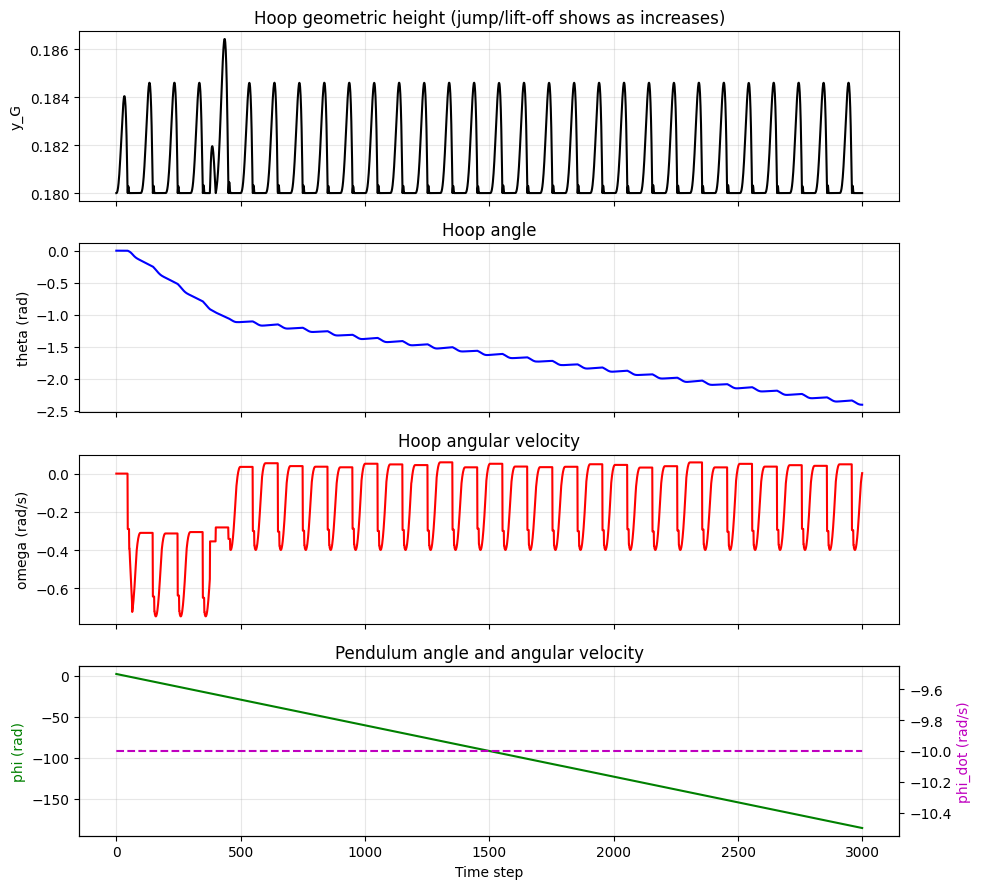

In [21]:
# Plot geometric height, angle, angular velocity, and pendulum angle
theta = q[2, :]
omega = u[2, :]
phi = q[3, :] if q.shape[0] > 3 else np.zeros_like(theta)
phi_dot = u[3, :] if u.shape[0] > 3 else np.zeros_like(omega)
yG = q[1, :]

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)

axes[0].plot(yG, 'k-', linewidth=1.5)
axes[0].set_ylabel('y_G')
axes[0].set_title('Hoop geometric height (jump/lift-off shows as increases)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(theta, 'b-', linewidth=1.5)
axes[1].set_ylabel('theta (rad)')
axes[1].set_title('Hoop angle')
axes[1].grid(True, alpha=0.3)

axes[2].plot(omega, 'r-', linewidth=1.5)
axes[2].set_ylabel('omega (rad/s)')
axes[2].set_title('Hoop angular velocity')
axes[2].grid(True, alpha=0.3)

ax3b = axes[3].twinx()
axes[3].plot(phi, 'g-', linewidth=1.5, label='phi')
ax3b.plot(phi_dot, 'm--', linewidth=1.5, label='phi_dot')
axes[3].set_ylabel('phi (rad)', color='g')
ax3b.set_ylabel('phi_dot (rad/s)', color='m')
axes[3].set_xlabel('Time step')
axes[3].set_title('Pendulum angle and angular velocity')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

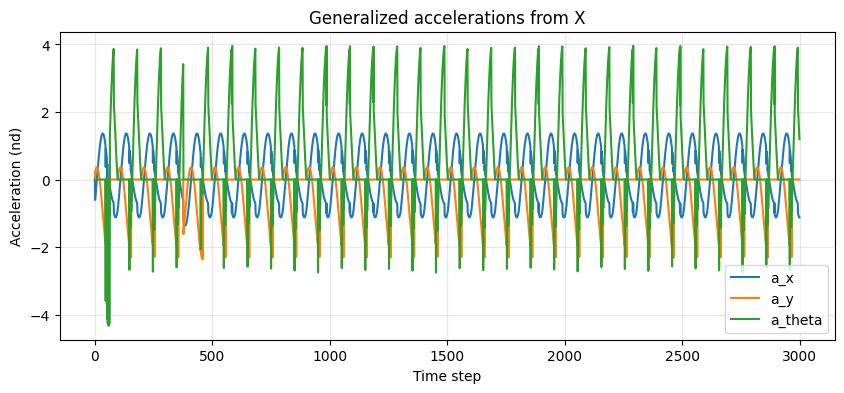

In [22]:
# Plot acceleration components from X array (a_x, a_y, a_theta) if present
if X.shape[0] >= 3:
    a_x = X[0, :]
    a_y = X[1, :]
    a_th = X[2, :]

    plt.figure(figsize=(10, 4))
    plt.plot(a_x, label='a_x')
    plt.plot(a_y, label='a_y')
    plt.plot(a_th, label='a_theta')
    plt.xlabel('Time step')
    plt.ylabel('Acceleration (nd)')
    plt.title('Generalized accelerations from X')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("X does not contain at least 3 acceleration components.")

[animation] Using output: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\hoop with a pendulum and stairs (semi-smooth)\outputs\hoop_pendulum_2026-04-03_23-24-30
[animation] q[:,0] = [0.2       0.18      0.        2.0943951]
[animation] Loaded gNx_save.npy shape=(3000,), gNy_save.npy shape=(3000,)
[animation] gNx range: [0.0000, 0.2351]
[animation] gNy range: [-0.0000, 0.0064]
[animation] dual_contact_save.npy loaded, dual active at 0 steps
Saving GIF animation to: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\hoop with a pendulum and stairs (semi-smooth)\outputs\hoop_pendulum_2026-04-03_23-24-30\hulahoop_motion_hoop_pendulum_2026-04-03_23-24-30.gif
GIF saved to: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\hoop with a pendulum and stairs (semi-smooth)\outputs\hoop_pendulum_2026-04-03_23-24-30\hulahoop_motion_hoop_pendulum_2026-04-03_23-24-30.gif
Converting GIF to MP4: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\h

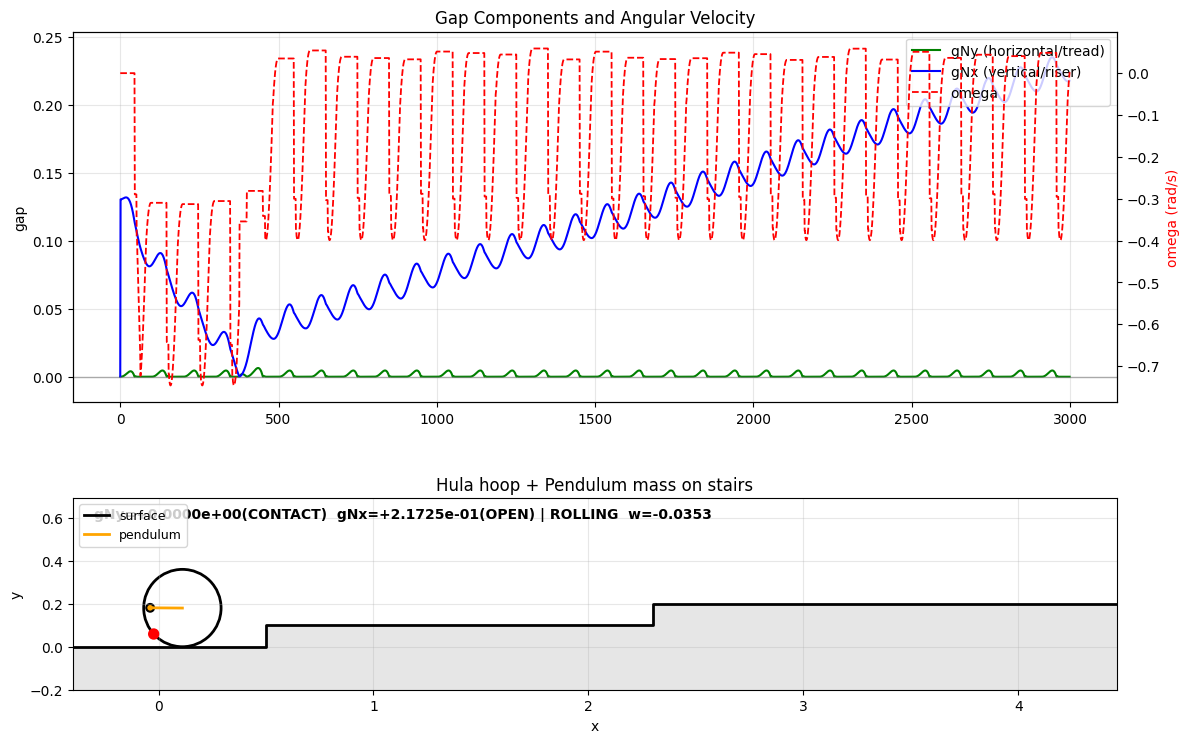

In [23]:
import matplotlib.animation as animation
from matplotlib.patches import Circle

# Defensive reload: if you changed OUTPUT_DIR, rerunning this cell picks up new data.
q = np.load(OUTPUT_DIR / "q_save.npy")
u = np.load(OUTPUT_DIR / "u_save.npy")
X = np.load(OUTPUT_DIR / "X_save.npy")
params_path = OUTPUT_DIR / "params.json"
params = json.loads(params_path.read_text(encoding="utf-8")) if params_path.exists() else {}
print("[animation] Using output:", OUTPUT_DIR)
print("[animation] q[:,0] =", q[:, 0])

# Reload stair segments from .npy (matches simulation output)
_seg_path = OUTPUT_DIR / "stair_segments.npy"
if _seg_path.exists():
    stair_segments = np.load(_seg_path)
else:
    stair_segments = np.array([[-1e6, 0.0, 1e6, 0.0]])

# Load pendulum data if available
try:
    phi = np.load(OUTPUT_DIR / "phi_save.npy")
    has_pendulum = True
except FileNotFoundError:
    phi = np.zeros(q.shape[1])
    has_pendulum = False
    print("[animation] No pendulum data found; visualizing as fixed")

# Parameters (prefer saved params.json)
R = float(params.get("R", 0.1))
l_pendulum = float(params.get("l_pendulum", 0.5))

xG = q[0, :]
yG = q[1, :]
theta = q[2, :]
omega = u[2, :]

# Load separated gap values directly from simulation output (gNx, gNy).
_gNx_path = OUTPUT_DIR / "gNx_save.npy"
_gNy_path = OUTPUT_DIR / "gNy_save.npy"
_dual_path = OUTPUT_DIR / "dual_contact_save.npy"

if _gNx_path.exists() and _gNy_path.exists():
    gNx = np.load(_gNx_path)         # 1-D array (ntime,)
    gNy = np.load(_gNy_path)         # 1-D array (ntime,)
    gN_contact = np.minimum(gNx, gNy)
    print(f"[animation] Loaded gNx_save.npy shape={gNx.shape}, gNy_save.npy shape={gNy.shape}")
    print(f"[animation] gNx range: [{np.nanmin(gNx):.4f}, {np.nanmax(gNx):.4f}]")
    print(f"[animation] gNy range: [{np.nanmin(gNy):.4f}, {np.nanmax(gNy):.4f}]")
else:
    print("[animation] WARNING: gNx_save.npy / gNy_save.npy not found. Re-run the simulation.")
    gNx = np.full(len(xG), np.nan)
    gNy = np.full(len(xG), np.nan)
    gN_contact = np.full(len(xG), np.nan)

if _dual_path.exists():
    dual_contact = np.load(_dual_path)
    print(f"[animation] dual_contact_save.npy loaded, dual active at {np.sum(dual_contact)} steps")
else:
    dual_contact = np.zeros(len(xG), dtype=int)

# Hide inactive sentinel values from the plot.
gNy_plot = gNy.astype(float).copy()
gNx_plot = gNx.astype(float).copy()
inactive_gNx_mask = gNx_plot > 1e5
gNx_plot[inactive_gNx_mask] = np.nan
has_active_gNx = bool(np.any(np.isfinite(gNx_plot)))

finite_gap_arrays = []
if np.any(np.isfinite(gNy_plot)):
    finite_gap_arrays.append(gNy_plot[np.isfinite(gNy_plot)])
if has_active_gNx:
    finite_gap_arrays.append(gNx_plot[np.isfinite(gNx_plot)])

if finite_gap_arrays:
    gap_all = np.concatenate(finite_gap_arrays)
    gap_min = float(np.min(gap_all))
    gap_max = float(np.max(gap_all))
    gap_span = max(gap_max - gap_min, 1e-6)
    gap_pad = 0.08 * gap_span
    gap_ylim = (gap_min - gap_pad, gap_max + gap_pad)
else:
    gap_ylim = (-1.0, 1.0)

# Pendulum mass position
if has_pendulum:
    xP = xG + l_pendulum * np.cos(phi)
    yP = yG + l_pendulum * np.sin(phi)
else:
    xP = xG + l_pendulum * np.cos(np.zeros_like(theta))
    yP = yG + l_pendulum * np.sin(np.zeros_like(theta))

# Point on hoop rim
xR = xG + R * np.cos(theta)
yR = yG + R * np.sin(theta)

# Figure layout
fig = plt.figure(figsize=(12, 8))

# 1) Gap time histories
ax1 = fig.add_subplot(2, 1, 1)
gap_lines = []
gap_labels = []

gNy_line, = ax1.plot(gNy_plot, "g-", lw=1.5, label="gNy (horizontal/tread)")
gap_lines.append(gNy_line)
gap_labels.append("gNy (horizontal/tread)")

if has_active_gNx:
    gNx_line, = ax1.plot(gNx_plot, "b-", lw=1.5, label="gNx (vertical/riser)")
    gap_lines.append(gNx_line)
    gap_labels.append("gNx (vertical/riser)")
else:
    ax1.text(0.02, 0.92, "gNx inactive in this run", transform=ax1.transAxes, color="b", fontsize=9)

ax1.axhline(0.0, color="gray", lw=1, alpha=0.6)
ax1.set_ylim(*gap_ylim)
ax1.set_ylabel("gap")
ax1.grid(True, alpha=0.3)
ax1.set_title("Gap Components and Angular Velocity")

ax1b = ax1.twinx()
omega_line, = ax1b.plot(u[2, :], "r--", lw=1.3, label="omega")
ax1b.set_ylabel("omega (rad/s)", color="r")
ax1b.ticklabel_format(axis="y", style="plain", useOffset=False)
ax1.legend(gap_lines + [omega_line], gap_labels + ["omega"], loc="upper right")

# 2) Animation
ax2 = fig.add_subplot(2, 1, 2)
ax2.set_aspect("equal")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("Hula hoop + Pendulum mass on stairs")
ax2.grid(True, alpha=0.3)

xmin = float(min(np.min(xG), np.min(xP)) - 2 * R)
xmax = float(max(np.max(xG), np.max(xP)) + 2 * R)
ymin = -0.2
ymax = float(max(np.max(yG), np.max(yP)) + 2 * R)

n_stairs_cfg = params.get("n_stairs", 0)
stair_x_start_cfg = params.get("stair_x_start", 0)
stair_width_cfg = params.get("stair_width", 0)
stair_height_cfg = params.get("stair_height", 0)
if n_stairs_cfg > 0:
    x_last = stair_x_start_cfg + n_stairs_cfg * stair_width_cfg
    h_top = n_stairs_cfg * stair_height_cfg
    xmin = min(xmin, stair_x_start_cfg - 2 * R)
    xmax = max(xmax, x_last + 2 * R)
    ymax = max(ymax, h_top + 2 * R)

ax2.set_xlim(xmin, xmax)
ax2.set_ylim(ymin, ymax)

stair_xs, stair_ys = build_stair_polyline_from_segments(
    stair_segments,
    x_pad_left=abs(xmin) + 1,
    x_pad_right=abs(xmax) + 1,
)
ax2.plot(stair_xs, stair_ys, "k-", lw=2, label="surface")
ax2.fill_between(stair_xs, stair_ys, ymin, color="0.90", zorder=0)

hoop_circle = Circle((xG[0], yG[0]), R, fill=False, edgecolor="black", linewidth=2)
ax2.add_patch(hoop_circle)

rim_point = Circle((xR[0], yR[0]), 0.12 * R if R > 0 else 0.02, color="blue", ec="black", lw=1.5)
ax2.add_patch(rim_point)

pend_patch = Circle((xP[0], yP[0]), 0.1 * R if R > 0 else 0.015, color="orange", ec="black", lw=1.5)
ax2.add_patch(pend_patch)

pend_line, = ax2.plot([xG[0], xP[0]], [yG[0], yP[0]], "orange", lw=2, label="pendulum")
status_text = ax2.text(0.02, 0.95, "", transform=ax2.transAxes, va="top", fontsize=10, fontweight="bold")
ax2.legend(loc="upper left", fontsize=9)

rotation_threshold = 0.01


def init():
    hoop_circle.center = (xG[0], yG[0])
    rim_point.center = (xR[0], yR[0])
    pend_patch.center = (xP[0], yP[0])
    pend_line.set_data([xG[0], xP[0]], [yG[0], yP[0]])
    status_text.set_text("")
    return hoop_circle, rim_point, pend_patch, pend_line, status_text


def animate(i):
    hoop_circle.center = (xG[i], yG[i])
    rim_point.center = (xR[i], yR[i])
    pend_patch.center = (xP[i], yP[i])
    pend_line.set_data([xG[i], xP[i]], [yG[i], yP[i]])

    if abs(omega[i]) > rotation_threshold:
        rim_point.set_color("red")
        rotation_status = "ROLLING"
    else:
        rim_point.set_color("blue")
        rotation_status = "SLIDING"

    gy = gNy[i]
    gx = gNx[i]
    y_status = "CONTACT" if gy <= 1e-6 else "AIR"
    x_status = "CONTACT" if (np.isfinite(gx) and gx <= 1e-6) else "OPEN"
    gx_str = f"{gx:+.4e}" if np.isfinite(gx) else "  N/A  "
    dual_str = " DUAL" if dual_contact[i] else ""
    status_text.set_text(
        f"gNy={gy:+.4e}({y_status})  gNx={gx_str}({x_status}){dual_str} | {rotation_status}  w={omega[i]:+.4f}"
    )
    return hoop_circle, rim_point, pend_patch, pend_line, status_text


step = 5
frames = range(0, q.shape[1], step)
anim = animation.FuncAnimation(fig, animate, init_func=init, frames=frames, interval=20, blit=True)

gif_path = OUTPUT_DIR / f"hulahoop_motion_{OUTPUT_DIR.name}.gif"
print("Saving GIF animation to:", gif_path)
anim.save(gif_path.as_posix(), writer=animation.PillowWriter(fps=30))
print("GIF saved to:", gif_path)

import imageio

mp4_path = OUTPUT_DIR / f"hulahoop_motion_{OUTPUT_DIR.name}.mp4"
print("Converting GIF to MP4:", mp4_path)
reader = imageio.get_reader(gif_path.as_posix())
mp4_writer = imageio.get_writer(mp4_path.as_posix(), fps=30, codec="libx264", quality=8)
for frame in reader:
    if frame.shape[-1] == 4:
        frame = frame[:, :, :3]
    mp4_writer.append_data(frame)
reader.close()
mp4_writer.close()
print("MP4 saved to:", mp4_path)

plt.tight_layout()
plt.show()

Common y-scale max abs: 0.235078
gNy range: [-1.14709e-11, 0.00642004]
gNx range: [0, 0.235078]


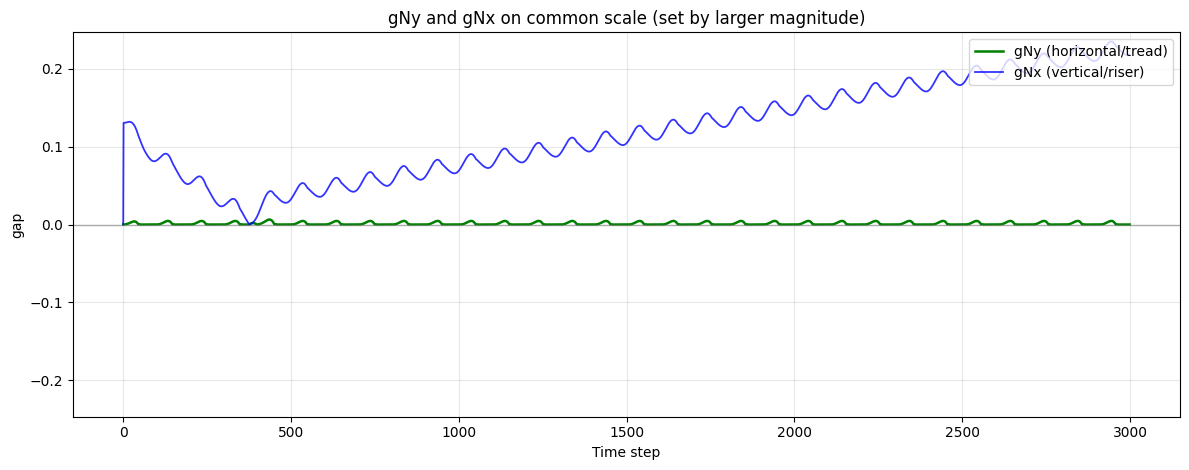

In [24]:
# Plot both gap components using the scale of the larger signal
if 'gNy' not in globals() or 'gNx' not in globals():
    raise RuntimeError("Run Cell 5 first to load gNy/gNx")

gNy_plot = gNy.astype(float).copy()
gNx_plot = gNx.astype(float).copy()
# Mask sentinel values
gNx_plot[gNx_plot > 1e5] = np.nan

# Use a common y-range based on the bigger magnitude
y_abs_max = float(np.nanmax(np.abs(np.concatenate([gNy_plot, gNx_plot[np.isfinite(gNx_plot)]]))))
if not np.isfinite(y_abs_max) or y_abs_max <= 0:
    y_abs_max = 1.0

print(f"Common y-scale max abs: {y_abs_max:.6g}")
print(f"gNy range: [{np.nanmin(gNy_plot):.6g}, {np.nanmax(gNy_plot):.6g}]")
print(f"gNx range: [{np.nanmin(gNx_plot):.6g}, {np.nanmax(gNx_plot):.6g}]")

fig_scale, ax_scale = plt.subplots(1, 1, figsize=(12, 4.8))
ax_scale.plot(gNy_plot, 'g-', lw=1.8, label='gNy (horizontal/tread)')
ax_scale.plot(gNx_plot, 'b-', lw=1.3, alpha=0.8, label='gNx (vertical/riser)')
ax_scale.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax_scale.set_ylim(-1.05 * y_abs_max, 1.05 * y_abs_max)
ax_scale.set_xlabel('Time step')
ax_scale.set_ylabel('gap')
ax_scale.set_title('gNy and gNx on common scale (set by larger magnitude)')
ax_scale.grid(True, alpha=0.3)
ax_scale.legend(loc='upper right')

plt.tight_layout()
plt.show()

gNx_save shape: (3000,),  gNy_save shape: (3000,)
gNdot shape: (2, 3000) (2 contact(s))
gNddot shape: (2, 3000)
lambdaN shape: (2, 3000)
lambdaF shape: (2, 3000)


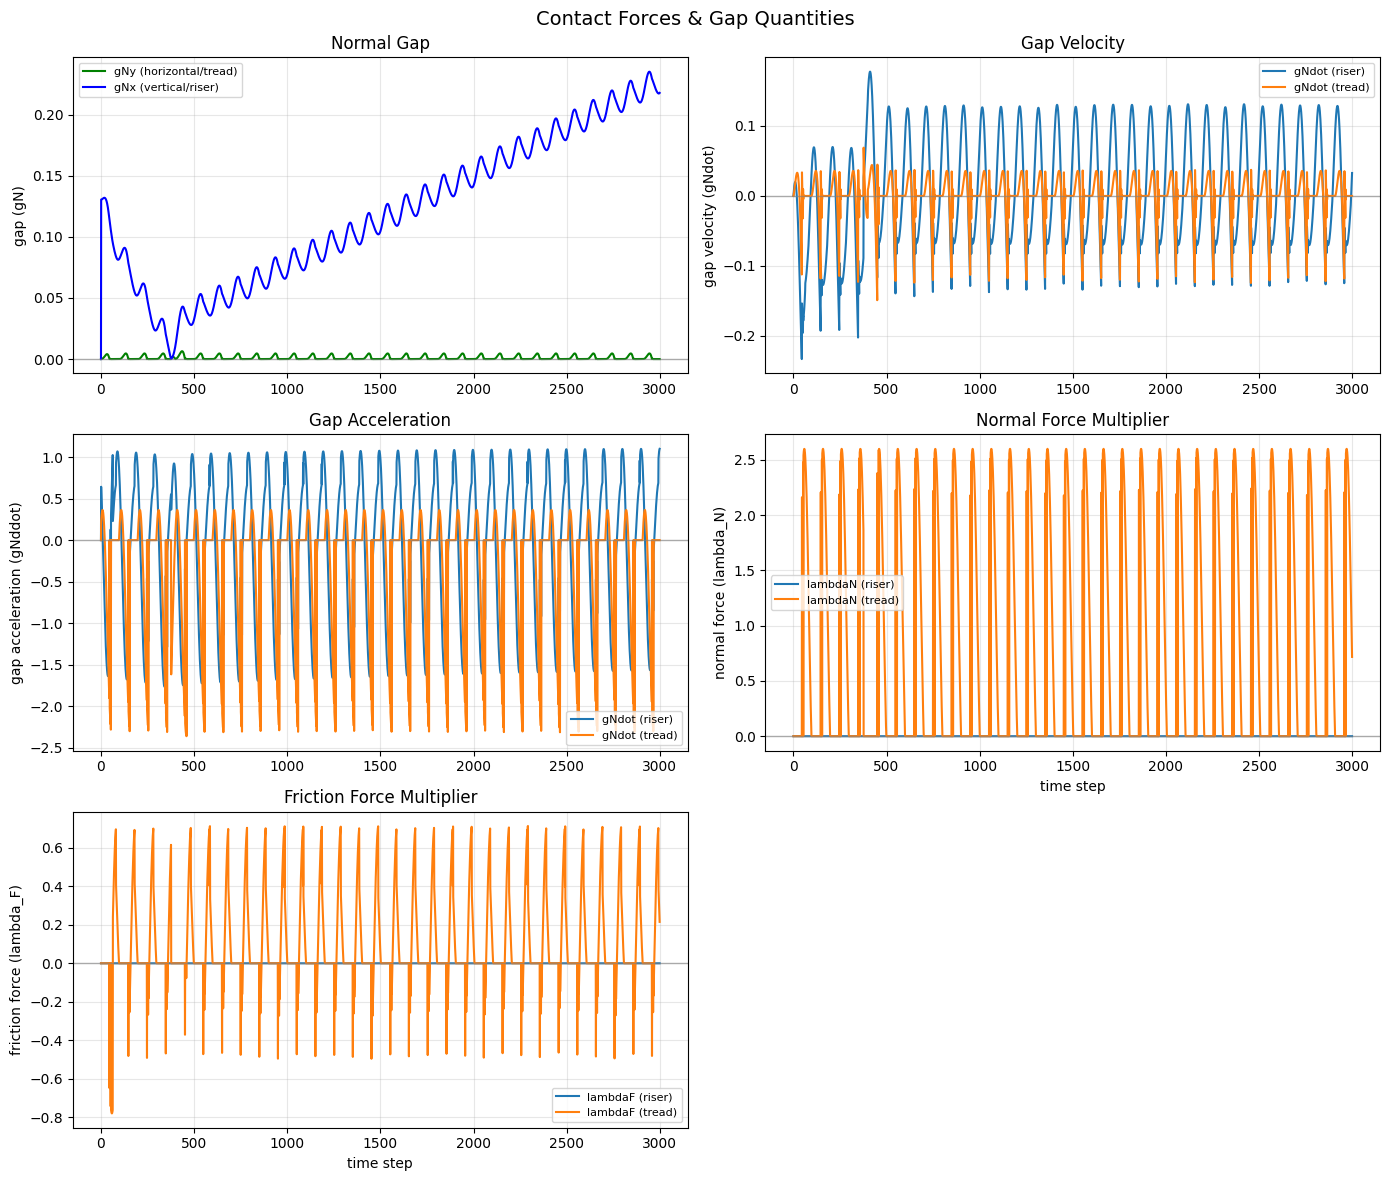

In [25]:

# Load and plot gN, gNdot, gNddot, lambda_N, lambda_F
gNdot = np.load(OUTPUT_DIR / "gNdot_save.npy")
gNddot = np.load(OUTPUT_DIR / "gNddot_save.npy")
lambdaN = np.load(OUTPUT_DIR / "lambdaN_save.npy")

# Load separated gap files (gNx = riser, gNy = tread)
_gNx_path = OUTPUT_DIR / "gNx_save.npy"
_gNy_path = OUTPUT_DIR / "gNy_save.npy"
if _gNx_path.exists() and _gNy_path.exists():
    gNx_comp = np.load(_gNx_path)
    gNy_comp = np.load(_gNy_path)
    has_gN = True
    print(f"gNx_save shape: {gNx_comp.shape},  gNy_save shape: {gNy_comp.shape}")
else:
    has_gN = False
    print("gNx_save.npy / gNy_save.npy not found — re-run the simulation to generate them")

# Try loading lambdaF_save.npy first, fall back to gammaF_save.npy for older simulations
try:
    lambdaF = np.load(OUTPUT_DIR / "lambdaF_save.npy")
except FileNotFoundError:
    lambdaF = np.load(OUTPUT_DIR / "gammaF_save.npy")

nN = gNdot.shape[0]
nF = lambdaF.shape[0]
print("gNdot shape:", gNdot.shape, f"({nN} contact(s))")
print("gNddot shape:", gNddot.shape)
print("lambdaN shape:", lambdaN.shape)
print("lambdaF shape:", lambdaF.shape)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# ── Figure 1: gN, gNdot, gNddot, lambdaN, lambdaF ───────────────────
fig_forces, axes_f = plt.subplots(3, 2, figsize=(14, 12))
fig_forces.suptitle('Contact Forces & Gap Quantities', fontsize=14)

# 1) gN (gap values) — gNx = vertical/riser, gNy = horizontal/tread
ax = axes_f[0, 0]
if has_gN:
    ax.plot(gNy_comp, color='g', lw=1.5, label='gNy (horizontal/tread)')
    gNx_vis = gNx_comp.astype(float).copy()
    gNx_vis[gNx_vis > 1e5] = np.nan
    ax.plot(gNx_vis, color='b', lw=1.5, label='gNx (vertical/riser)')
ax.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax.set_ylabel('gap (gN)')
ax.set_title('Normal Gap')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 2) gNdot
ax = axes_f[0, 1]
labels_N = ['gNdot (riser)', 'gNdot (tread)']
for i in range(nN):
    lbl = labels_N[i] if i < len(labels_N) else f"contact {i}"
    ax.plot(gNdot[i, :], color=colors[i % len(colors)], lw=1.5, label=lbl)
ax.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax.set_ylabel('gap velocity (gNdot)')
ax.set_title('Gap Velocity')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 3) gNddot
ax = axes_f[1, 0]
for i in range(nN):
    lbl = labels_N[i] if i < len(labels_N) else f"contact {i}"
    ax.plot(gNddot[i, :], color=colors[i % len(colors)], lw=1.5, label=lbl)
ax.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax.set_ylabel('gap acceleration (gNddot)')
ax.set_title('Gap Acceleration')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 4) lambda_N
ax = axes_f[1, 1]
labels_lN = ['lambdaN (riser)', 'lambdaN (tread)']
for i in range(nN):
    lbl = labels_lN[i] if i < len(labels_lN) else f"contact {i}"
    ax.plot(lambdaN[i, :], color=colors[i % len(colors)], lw=1.5, label=lbl)
ax.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax.set_xlabel('time step')
ax.set_ylabel('normal force (lambda_N)')
ax.set_title('Normal Force Multiplier')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 5) lambda_F
ax = axes_f[2, 0]
labels_F = ['lambdaF (riser)', 'lambdaF (tread)']
for i in range(nF):
    lbl = labels_F[i] if i < len(labels_F) else f"contact {i}"
    ax.plot(lambdaF[i, :], color=colors[i % len(colors)], lw=1.5, label=lbl)
ax.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax.set_xlabel('time step')
ax.set_ylabel('friction force (lambda_F)')
ax.set_title('Friction Force Multiplier')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

axes_f[2, 1].axis('off')

plt.tight_layout()
plt.show()


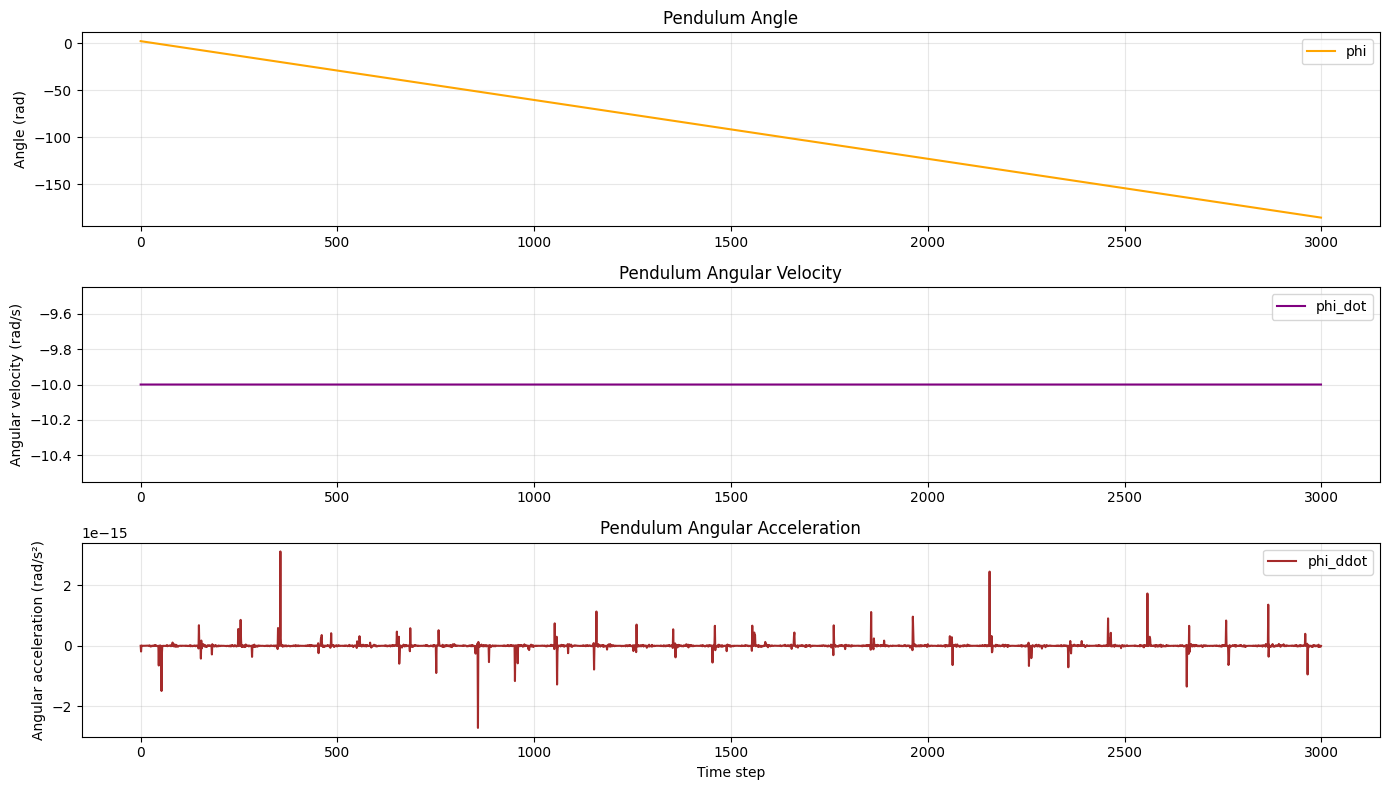

In [26]:
# Load and plot pendulum data
try:
    phi = np.load(OUTPUT_DIR / "phi_save.npy")
    phi_dot = np.load(OUTPUT_DIR / "phi_dot_save.npy")
    phi_ddot = np.load(OUTPUT_DIR / "phi_ddot_save.npy")
    
    fig_pend = plt.figure(figsize=(14, 8))
    
    # 1) Pendulum angle
    ax1 = fig_pend.add_subplot(3, 1, 1)
    ax1.plot(phi, 'orange', lw=1.5, label='phi')
    ax1.set_ylabel('Angle (rad)')
    ax1.set_title('Pendulum Angle')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # 2) Pendulum angular velocity
    ax2 = fig_pend.add_subplot(3, 1, 2)
    ax2.plot(phi_dot, 'purple', lw=1.5, label='phi_dot')
    ax2.set_ylabel('Angular velocity (rad/s)')
    ax2.set_title('Pendulum Angular Velocity')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # 3) Pendulum angular acceleration
    ax3 = fig_pend.add_subplot(3, 1, 3)
    ax3.plot(phi_ddot, 'brown', lw=1.5, label='phi_ddot')
    ax3.set_ylabel('Angular acceleration (rad/s²)')
    ax3.set_xlabel('Time step')
    ax3.set_title('Pendulum Angular Acceleration')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    plt.tight_layout()
    plt.show()
    
except FileNotFoundError as e:
    print(f"Pendulum data not found: {e}")


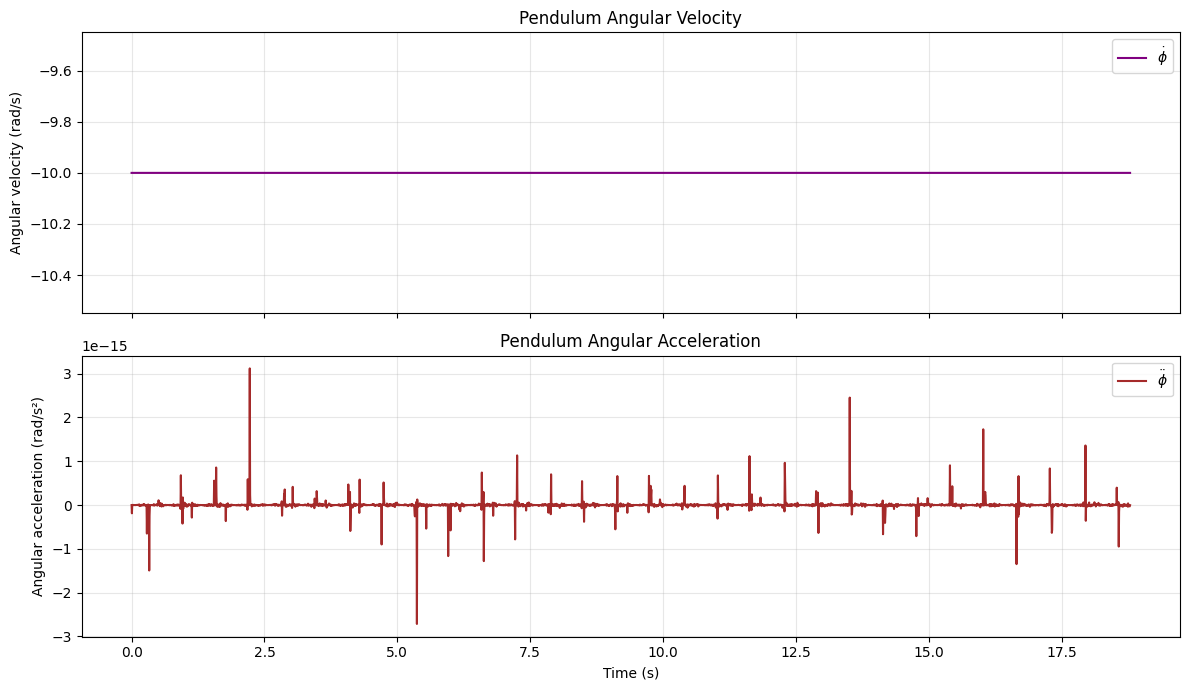

In [27]:
# Pendulum angular velocity & angular acceleration
if has_pendulum_data:
    dtime = params.get("dtime", 1.0)
    t = np.arange(len(phi_dot)) * dtime

    fig_pend_va, (ax_omega_p, ax_alpha_p) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    # --- Angular velocity (phi_dot) ---
    ax_omega_p.plot(t, phi_dot, color='purple', lw=1.5, label=r'$\dot{\phi}$')
    ax_omega_p.set_ylabel('Angular velocity (rad/s)')
    ax_omega_p.set_title('Pendulum Angular Velocity')
    ax_omega_p.legend()
    ax_omega_p.grid(True, alpha=0.3)

    # --- Angular acceleration (phi_ddot) ---
    ax_alpha_p.plot(t, phi_ddot, color='brown', lw=1.5, label=r'$\ddot{\phi}$')
    ax_alpha_p.set_ylabel('Angular acceleration (rad/s²)')
    ax_alpha_p.set_xlabel('Time (s)')
    ax_alpha_p.set_title('Pendulum Angular Acceleration')
    ax_alpha_p.legend()
    ax_alpha_p.grid(True, alpha=0.3)

    fig_pend_va.tight_layout()
    plt.show()
else:
    print("No pendulum data available — skipping phi_dot / phi_ddot plots.")